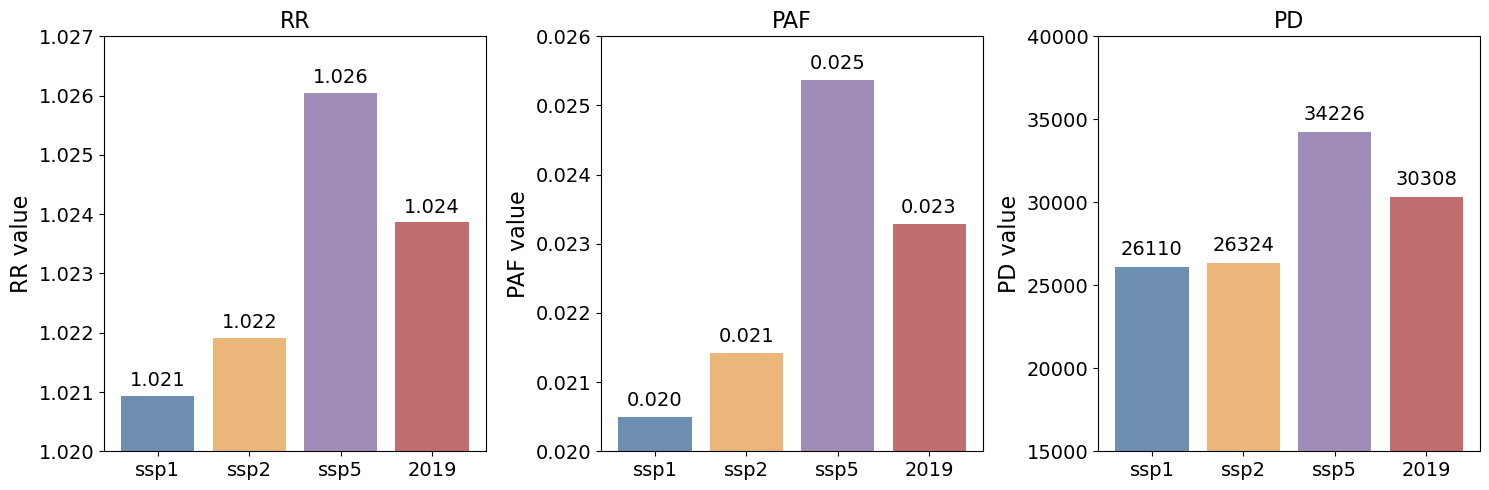

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- 1. Data preparation ----------------------
# Build dataframe with the panel-c data (RR / PAF / PD per scenario)
data = {
    'indicator': ['RR', 'PAF', 'PD'],
    'ssp1': [1.02094, 0.02049, 26110],
    'ssp2': [1.02191, 0.02142, 26324],
    'ssp5': [1.02605, 0.02537, 34226],
    '2019': [1.02386, 0.02329, 30308]  # 2019 PD value aligned to same decimal format
}
df = pd.DataFrame(data)

# Melt so that x-axis = scenario, y-axis = value
df_melt = df.melt(id_vars='indicator', var_name='scenario', value_name='value')

# ---------------------- 2. Plot settings ----------------------
# Per-scenario colours (ssp1 / ssp2 / ssp5 / 2019)
colors = ['#6e8fb2', '#eab67a', '#9f8db8', '#c16e71']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row x 3 columns, total 15x5

# ---------------------- 3. Draw each subplot ----------------------
# Subplot 1: RR
rr_data = df_melt[df_melt['indicator'] == 'RR']
ax1 = axes[0]
bars1 = ax1.bar(rr_data['scenario'], rr_data['value'], color=colors)
ax1.set_title('RR', fontsize=16)
ax1.set_ylabel('RR value', fontsize=16)
ax1.set_ylim(1.02, 1.027)  # Restrict y-range to highlight differences
# Annotate bar tops (5 decimals to match raw data precision)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=14)

# Subplot 2: PAF
paf_data = df_melt[df_melt['indicator'] == 'PAF']
ax2 = axes[1]
bars2 = ax2.bar(paf_data['scenario'], paf_data['value'], color=colors)
ax2.set_title('PAF', fontsize=16)
ax2.set_ylabel('PAF value', fontsize=16)
ax2.set_ylim(0.02, 0.026)  # Restrict y-range to highlight differences
# Annotate bar tops (4 decimals)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=14)

# Subplot 3: PD
pd_data = df_melt[df_melt['indicator'] == 'PD']
ax3 = axes[2]
bars3 = ax3.bar(pd_data['scenario'], pd_data['value'], color=colors)
ax3.set_title('PD', fontsize=16)
ax3.set_ylabel('PD value', fontsize=16)
ax3.set_ylim(15000, 40000)
# Annotate bar tops (integer display for readability)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 500, f'{height:.0f}',
              ha='center', va='bottom', fontsize=14)

# ---------------------- 4. Global tweaks ----------------------
# Unify x-axis tick label size
for ax in axes:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

# Adjust subplot spacing to avoid overlap
plt.tight_layout()
plt.show()


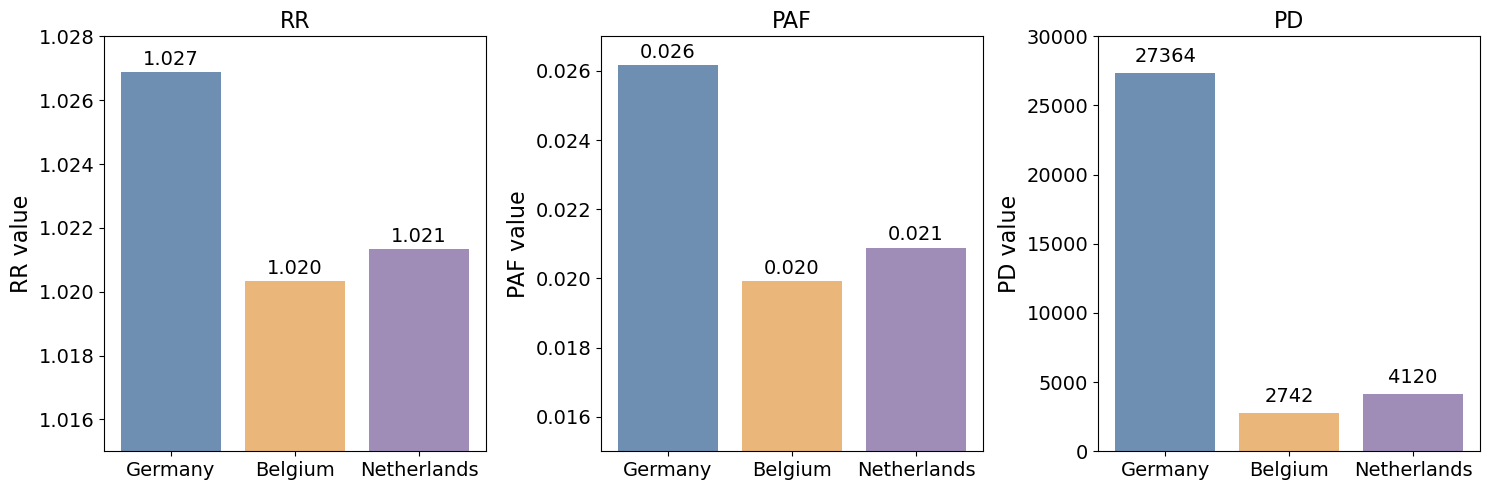

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- 1. Data preparation ----------------------
# Build dataframe with RR / PAF / PD for Germany, Belgium, Netherlands
data = {
    'indicator': ['RR', 'PAF', 'PD'],
    'Germany': [1.02689, 0.02617, 27364],
    'Belgium': [1.02033, 0.01992, 2742],
    'Netherlands': [1.02134, 0.02088, 4120]
}
df = pd.DataFrame(data)

# Melt so that x-axis = country, y-axis = value
df_melt = df.melt(id_vars='indicator', var_name='country', value_name='value')

# ---------------------- 2. Plot settings ----------------------
# Per-country colours (3 countries)
colors = ['#6e8fb2', '#eab67a', '#9f8db8']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row x 3 columns, keep 15x5

# ---------------------- 3. Draw each subplot ----------------------
# Subplot 1: RR
rr_data = df_melt[df_melt['indicator'] == 'RR']
ax1 = axes[0]
bars1 = ax1.bar(rr_data['country'], rr_data['value'], color=colors)
ax1.set_title('RR', fontsize=16)
ax1.set_ylabel('RR value', fontsize=16)
ax1.set_ylim(1.015, 1.028)  # Fit new RR range, highlight differences
# Annotate bar tops (5 decimals to match raw precision)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=14)

# Subplot 2: PAF
paf_data = df_melt[df_melt['indicator'] == 'PAF']
ax2 = axes[1]
bars2 = ax2.bar(paf_data['country'], paf_data['value'], color=colors)
ax2.set_title('PAF', fontsize=16)
ax2.set_ylabel('PAF value', fontsize=16)
ax2.set_ylim(0.015, 0.027)  # Fit new PAF range
# Annotate bar tops (4 decimals)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=14)

# Subplot 3: PD
pd_data = df_melt[df_melt['indicator'] == 'PD']
ax3 = axes[2]
bars3 = ax3.bar(pd_data['country'], pd_data['value'], color=colors)
ax3.set_title('PD', fontsize=16)
ax3.set_ylabel('PD value', fontsize=16)
ax3.set_ylim(0, 30000)  # Fit new PD data (max 27364)
# Annotate bar tops (integer, more intuitive for PD)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{height:.0f}', ha='center', va='bottom', fontsize=14)

# ---------------------- 4. Global tweaks ----------------------
# Unify axis tick label size
for ax in axes:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

# Adjust subplot spacing to avoid label overlap
plt.tight_layout()
plt.show()
